# 03 · Red neuronal LSTM y comparación final

Se entrena una red LSTM (*Long Short-Term Memory*) que procesa directamente la secuencia de 30 ciclos × 14 sensores, sin *features* diseñadas manualmente, y se compara con el mejor baseline (XGBoost, RMSE 12,57).

**Arquitectura**
```
Entrada (30 ciclos × 14 sensores)
  → LSTM(64, return_sequences) → Dropout(0,2)
  → LSTM(32)                   → Dropout(0,2)
  → Dense(16, ReLU) → Dense(1) → Rescaling(×125)
```

La capa final `Rescaling` permite que la red opere internamente en el rango [0, 1] y entregue la RUL en ciclos. Sin este ajuste, las capas LSTM (activaciones acotadas en [−1, 1]) se saturan al intentar producir valores de hasta 125 y el modelo converge a una predicción constante.

Se mantienen las condiciones del notebook 02: mismos 20 motores de validación, escalado ajustado solo con entrenamiento y evaluación única sobre el test oficial.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data_processing import (
    load_cmapss, add_train_rul, get_feature_columns, split_units,
    fit_scaler, apply_scaler, make_sequences, make_test_sequences, DEFAULT_RUL_CAP,
)
from src.models import build_lstm, default_callbacks, set_seeds, evaluate

DATA_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"
for d in (FIG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUBSET = "FD001"
WINDOW = 30
SEED = 42
BATCH_SIZE = 256
MAX_EPOCHS = 100
N_SEEDS = 3   # modelos finales con semillas distintas (estabilidad y ensamble)

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#b5b3ad"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.6, "axes.titleweight": "bold", "lines.linewidth": 2,
})
tf.get_logger().setLevel("ERROR")  # oculta avisos internos de TensorFlow
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


## 1. Preparación de secuencias

In [2]:
train, test, rul_test = load_cmapss(DATA_DIR, SUBSET)
train = add_train_rul(train, cap=DEFAULT_RUL_CAP)
FEATURES = get_feature_columns(train)

# Misma separación por motor que en el notebook 02 (misma semilla)
tr, val = split_units(train, val_frac=0.2, seed=SEED)
assert set(tr["unit"]).isdisjoint(set(val["unit"]))

# Escalado Min-Max ajustado solo con los motores de entrenamiento
scaler = fit_scaler(tr, FEATURES)
tr_s, val_s = apply_scaler(tr, scaler, FEATURES), apply_scaler(val, scaler, FEATURES)

X_tr, y_tr = make_sequences(tr_s, FEATURES, window=WINDOW)
X_val, y_val = make_sequences(val_s, FEATURES, window=WINDOW)

print(f"Motores de validación: {sorted(val['unit'].unique().tolist())}")
print(f"X_tr : {X_tr.shape}  (muestras, ciclos, sensores)")
print(f"X_val: {X_val.shape}")

Motores de validación: [8, 9, 13, 18, 37, 46, 48, 50, 55, 62, 64, 69, 72, 74, 76, 84, 85, 87, 90, 95]
X_tr : (14070, 30, 14)  (muestras, ciclos, sensores)
X_val: (3661, 30, 14)


Cada muestra corresponde a una ventana de 30 ciclos consecutivos de un motor; la etiqueta es la RUL en el último ciclo de la ventana. Las ventanas se generan con desplazamiento de un ciclo.

## 2. Entrenamiento con validación

In [3]:
set_seeds(SEED)
model = build_lstm(WINDOW, len(FEATURES), output_scale=DEFAULT_RUL_CAP)
model.summary()

Model: "lstm_rul"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
t0 = time.time()
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=default_callbacks(patience=10),
    verbose=2,
)
hist = pd.DataFrame(history.history)
best_epoch = int(hist["val_loss"].idxmin()) + 1
print(f"\nTiempo: {time.time() - t0:.0f} s  |  mejor época: {best_epoch} de {len(hist)}")

Epoch 1/100
55/55 - 3s - 61ms/step - loss: 1202.4362 - rmse: 34.6762 - val_loss: 468.6411 - val_rmse: 21.6481 - learning_rate: 0.0010
Epoch 2/100
55/55 - 2s - 33ms/step - loss: 551.4886 - rmse: 23.4838 - val_loss: 513.4728 - val_rmse: 22.6599 - learning_rate: 0.0010
Epoch 3/100
55/55 - 2s - 35ms/step - loss: 506.0058 - rmse: 22.4946 - val_loss: 489.6482 - val_rmse: 22.1280 - learning_rate: 0.0010
Epoch 4/100
55/55 - 2s - 34ms/step - loss: 415.4201 - rmse: 20.3819 - val_loss: 365.0187 - val_rmse: 19.1055 - learning_rate: 0.0010
Epoch 5/100
55/55 - 2s - 35ms/step - loss: 322.0473 - rmse: 17.9457 - val_loss: 295.5167 - val_rmse: 17.1906 - learning_rate: 0.0010
Epoch 6/100
55/55 - 2s - 34ms/step - loss: 302.2849 - rmse: 17.3863 - val_loss: 315.2612 - val_rmse: 17.7556 - learning_rate: 0.0010
Epoch 7/100
55/55 - 2s - 34ms/step - loss: 274.1329 - rmse: 16.5570 - val_loss: 249.9790 - val_rmse: 15.8107 - learning_rate: 0.0010
Epoch 8/100
55/55 - 2s - 35ms/step - loss: 254.8419 - rmse: 15.9638 

**Callbacks:** `EarlyStopping` (paciencia de 10 épocas; restaura los pesos de la mejor época) y `ReduceLROnPlateau` (reduce la tasa de aprendizaje a la mitad ante estancamiento).

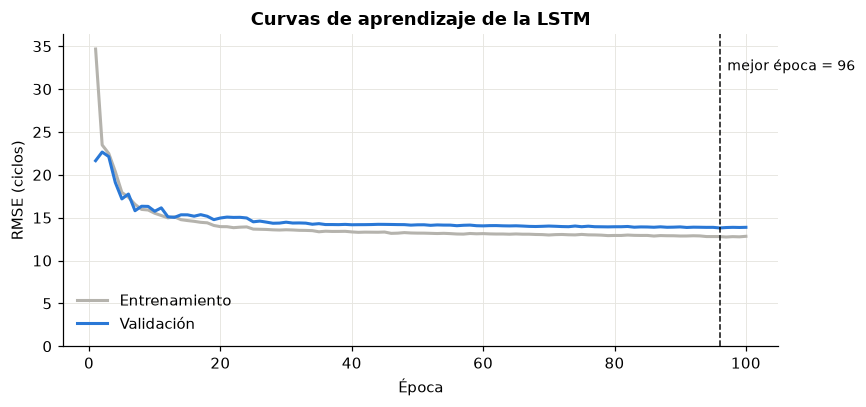

{'modelo': 'LSTM (validación)', 'RMSE': 13.8, 'MAE': 10.46, 'NASA_score': 10890.2}
Desviación de las predicciones: 39.0 ciclos (RUL real: 41.8)


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(hist.index + 1, hist["rmse"], color=GRAY, label="Entrenamiento")
ax.plot(hist.index + 1, hist["val_rmse"], color=BLUE, label="Validación")
ax.axvline(best_epoch, color="#0b0b0b", linestyle="--", linewidth=1)
ax.annotate(f"mejor época = {best_epoch}", xy=(best_epoch, ax.get_ylim()[1] * 0.9),
            xytext=(5, 0), textcoords="offset points", fontsize=9)
ax.set_title("Curvas de aprendizaje de la LSTM")
ax.set_xlabel("Época")
ax.set_ylabel("RMSE (ciclos)")
ax.set_ylim(0, min(60, hist[["rmse", "val_rmse"]].max().max() * 1.05))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_lstm_curvas_aprendizaje.png", bbox_inches="tight")
plt.show()

pred_val = model.predict(X_val, verbose=0).ravel()
print(evaluate(y_val, pred_val, "LSTM (validación)"))

# Control de calidad: un modelo colapsado predice casi el mismo valor para todas las ventanas
print(f"Desviación de las predicciones: {pred_val.std():.1f} ciclos (RUL real: {y_val.std():.1f})")
assert pred_val.std() > 0.25 * y_val.std(), "El modelo colapsó a una predicción constante"

Las curvas permiten verificar la convergencia y detectar sobreajuste. El error de validación puede ubicarse bajo el de entrenamiento, ya que el dropout solo se aplica durante el entrenamiento.

Se incluye un control de calidad: la desviación de las predicciones debe ser comparable a la de la RUL real. Un valor cercano a cero indica que la red colapsó a una predicción constante.

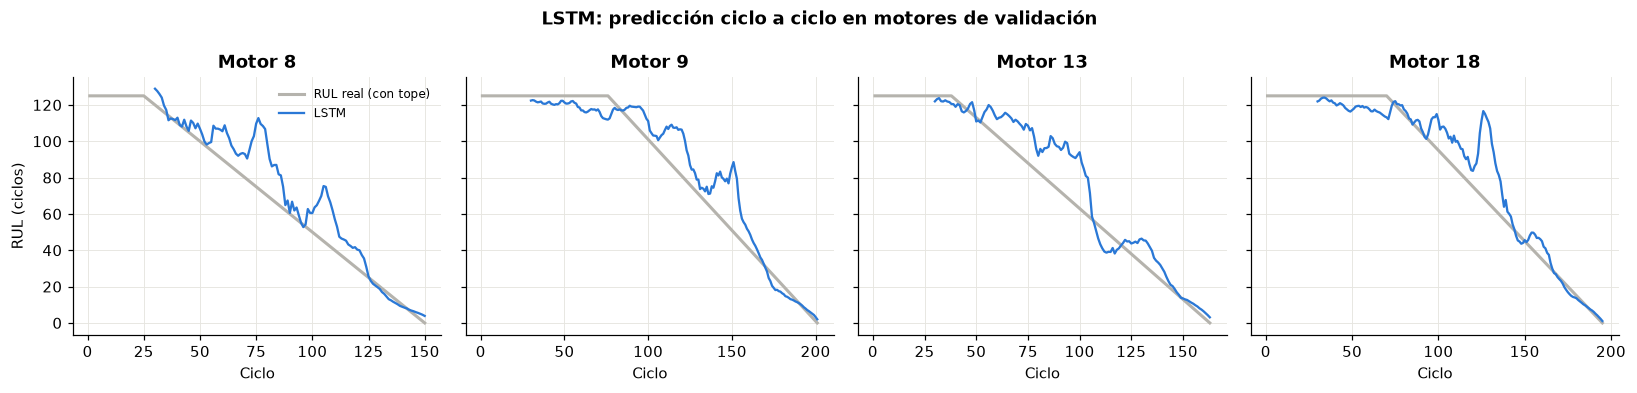

In [6]:
# Trayectorias: los mismos motores de validación del notebook 02
ejemplos = val["unit"].unique()[:4]
fig, axes = plt.subplots(1, len(ejemplos), figsize=(15, 3.6), sharey=True)
for ax, u in zip(axes, ejemplos):
    g = val_s[val_s["unit"] == u]
    Xu, yu = make_sequences(g, FEATURES, window=WINDOW)
    ciclos = g["cycle"].values[WINDOW - 1:]
    ax.plot(g["cycle"], g["RUL_capped"], color=GRAY, label="RUL real (con tope)")
    ax.plot(ciclos, model.predict(Xu, verbose=0).ravel(), color=BLUE, linewidth=1.5, label="LSTM")
    ax.set_title(f"Motor {u}")
    ax.set_xlabel("Ciclo")
axes[0].set_ylabel("RUL (ciclos)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("LSTM: predicción ciclo a ciclo en motores de validación", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_lstm_trayectorias.png", bbox_inches="tight")
plt.show()

La LSTM genera predicciones a partir del ciclo 30, una vez disponible la primera ventana completa. La comparación con XGBoost sobre los mismos motores se encuentra en `08_baseline_trayectorias.png`.

## 3. Modelo final y evaluación en test

El modelo final se reentrena con los 100 motores de entrenamiento durante el número de épocas seleccionado en validación. Dado que el resultado de una red neuronal depende de la inicialización aleatoria, se entrenan tres modelos con semillas distintas y se reporta:
- el RMSE medio ± desviación estándar (estabilidad), y
- el desempeño del ensamble que promedia sus predicciones.

In [7]:
# Escalado y secuencias con todos los motores de train
scaler_full = fit_scaler(train, FEATURES)
train_s = apply_scaler(train, scaler_full, FEATURES)
test_s = apply_scaler(test, scaler_full, FEATURES)

X_full, y_full = make_sequences(train_s, FEATURES, window=WINDOW)
X_test, test_units = make_test_sequences(test_s, FEATURES, window=WINDOW)
y_test = rul_test.set_index("unit").loc[test_units, "RUL_end"].clip(upper=DEFAULT_RUL_CAP).values

preds, resultados_semillas = [], []
t0 = time.time()
for i in range(N_SEEDS):
    seed = SEED + i
    set_seeds(seed)
    m = build_lstm(WINDOW, len(FEATURES), output_scale=DEFAULT_RUL_CAP)
    m.fit(X_full, y_full, epochs=best_epoch, batch_size=BATCH_SIZE, verbose=0)
    p = np.clip(m.predict(X_test, verbose=0).ravel(), 0, None)
    preds.append(p)
    resultados_semillas.append(evaluate(y_test, p, f"LSTM semilla {seed}"))
    print(f"✓ semilla {seed}: RMSE {resultados_semillas[-1]['RMSE']}  ({time.time() - t0:.0f} s)")
    if i == 0:
        m.save(MODEL_DIR / "lstm_fd001.keras")

pred_lstm = np.mean(preds, axis=0)
joblib.dump(scaler_full, MODEL_DIR / "lstm_scaler.joblib")

tabla_semillas = pd.DataFrame(resultados_semillas).set_index("modelo")
rmse_mean, rmse_std = tabla_semillas["RMSE"].mean(), tabla_semillas["RMSE"].std()
print(f"\nRMSE por modelo: {rmse_mean:.2f} ± {rmse_std:.2f}")
tabla_semillas

✓ semilla 42: RMSE 14.81  (241 s)
✓ semilla 43: RMSE 13.45  (453 s)
✓ semilla 44: RMSE 14.06  (665 s)

RMSE por modelo: 14.11 ± 0.68


,RMSE,MAE,NASA_score
modelo,,,
LSTM semilla 42,14.81,10.85,288.4
LSTM semilla 43,13.45,9.98,321.9
LSTM semilla 44,14.06,10.94,370.4


## 4. Comparación final

In [8]:
baselines = pd.read_csv(REPORT_DIR / "resultados_baselines.csv", index_col="modelo").drop(columns="conjunto")

lstm_rows = pd.DataFrame([
    evaluate(y_test, pred_lstm, f"LSTM (ensamble {N_SEEDS})"),
    {"modelo": "LSTM (modelo individual, promedio)",
     "RMSE": round(rmse_mean, 2),
     "MAE": round(tabla_semillas["MAE"].mean(), 2),
     "NASA_score": round(tabla_semillas["NASA_score"].mean(), 1)},
]).set_index("modelo")

final = pd.concat([lstm_rows, baselines]).sort_values("RMSE")
final.to_csv(REPORT_DIR / "resultados_finales.csv")
final

,RMSE,MAE,NASA_score
modelo,,,
XGBoost,12.57,9.66,237.2
LSTM (ensamble 3),12.81,9.93,256.5
Random Forest,13.53,10.47,296.1
"LSTM (modelo individual, promedio)",14.11,10.59,326.9
Ridge,17.30,13.95,572.5
Promedio,41.94,34.83,33354.5


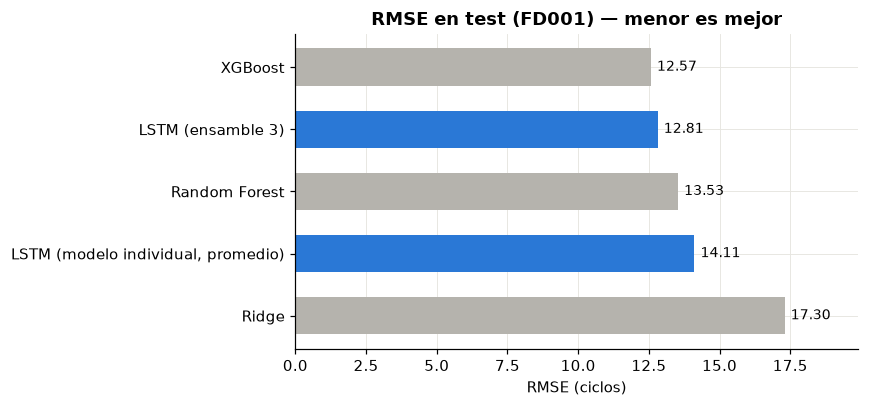

In [9]:
orden = final.drop(index="Promedio").sort_values("RMSE", ascending=False)
colores = [BLUE if "LSTM" in m else GRAY for m in orden.index]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(orden.index, orden["RMSE"], color=colores, height=0.6)
for y, v in enumerate(orden["RMSE"]):
    ax.annotate(f"{v:.2f}", xy=(v, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9)
ax.set_title("RMSE en test (FD001) — menor es mejor")
ax.set_xlabel("RMSE (ciclos)")
ax.set_xlim(0, orden["RMSE"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_comparacion_modelos.png", bbox_inches="tight")
plt.show()

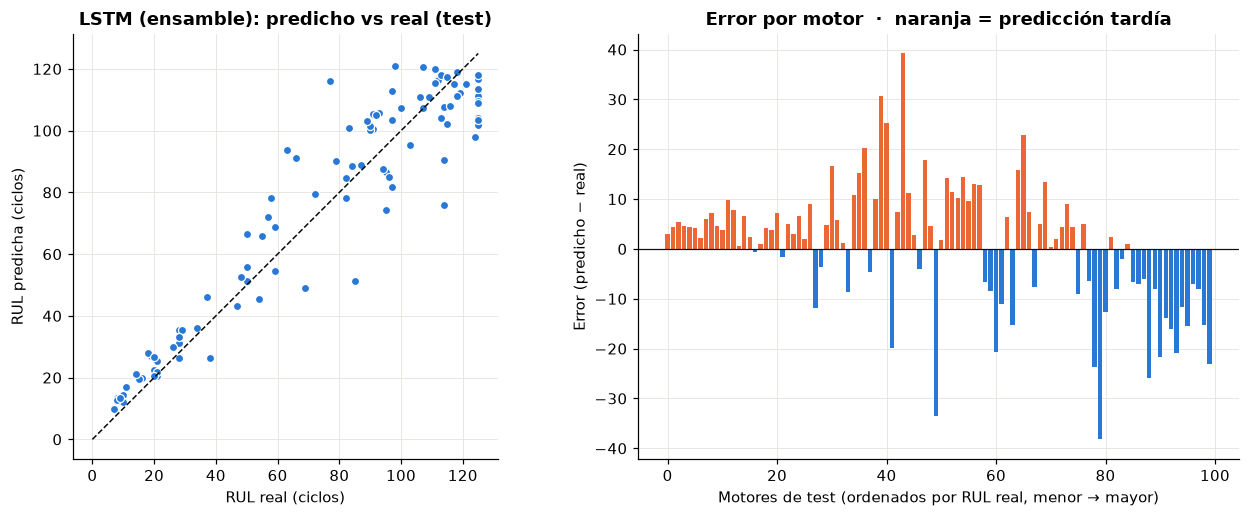

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.plot([0, DEFAULT_RUL_CAP], [0, DEFAULT_RUL_CAP], color="#0b0b0b", linewidth=1, linestyle="--")
ax.scatter(y_test, pred_lstm, s=28, color=BLUE, edgecolor="white", linewidth=0.8)
ax.set_xlabel("RUL real (ciclos)")
ax.set_ylabel("RUL predicha (ciclos)")
ax.set_title("LSTM (ensamble): predicho vs real (test)")
ax.set_aspect("equal")

ax = axes[1]
idx = np.argsort(y_test)
err = pred_lstm[idx] - y_test[idx]
ax.bar(range(len(err)), err, color=np.where(err > 0, ORANGE, BLUE), width=0.8)
ax.axhline(0, color="#0b0b0b", linewidth=0.8)
ax.set_xlabel("Motores de test (ordenados por RUL real, menor → mayor)")
ax.set_ylabel("Error (predicho − real)")
ax.set_title("Error por motor  ·  naranja = predicción tardía")

plt.tight_layout()
plt.savefig(FIG_DIR / "13_lstm_errores_test.png", bbox_inches="tight")
plt.show()

In [11]:
# ¿Dónde se equivoca cada modelo? Error absoluto según qué tan cerca de la falla está el motor
tramos = pd.cut(y_test, bins=[0, 25, 50, 75, 100, DEFAULT_RUL_CAP],
                labels=["0–25", "26–50", "51–75", "76–100", "101–125"], include_lowest=True)
abs_err = pd.DataFrame({"tramo_RUL_real": tramos, "LSTM": np.abs(pred_lstm - y_test)})
abs_err.groupby("tramo_RUL_real", observed=True).agg(
    motores=("LSTM", "size"), MAE_LSTM=("LSTM", "mean")).round(1)

,motores,MAE_LSTM
tramo_RUL_real,,
0–25,19,4.3
26–50,14,5.9
51–75,10,15.2
76–100,24,13.1
101–125,33,10.9


El error por tramo de RUL permite evaluar la confiabilidad del modelo en el tramo crítico para el mantenimiento (RUL baja).

## 5. Conclusiones

In [12]:
xgb_rmse = final.loc["XGBoost", "RMSE"]
ens_rmse = final.loc[f"LSTM (ensamble {N_SEEDS})", "RMSE"]
dif = (xgb_rmse - ens_rmse) / xgb_rmse

print(f"XGBoost (features diseñadas) : RMSE {xgb_rmse:.2f}")
print(f"LSTM individual              : RMSE {rmse_mean:.2f} ± {rmse_std:.2f}")
print(f"LSTM ensamble ({N_SEEDS})           : RMSE {ens_rmse:.2f}")
print(f"\nDiferencia LSTM ensamble vs XGBoost: {dif:+.1%} "
      f"({'mejora' if dif > 0 else 'empeora'} respecto a XGBoost)")

XGBoost (features diseñadas) : RMSE 12.57
LSTM individual              : RMSE 14.11 ± 0.68
LSTM ensamble (3)           : RMSE 12.81

Diferencia LSTM ensamble vs XGBoost: -1.9% (empeora respecto a XGBoost)


**Resultados**

| Modelo | RMSE | MAE | NASA score |
|---|---|---|---|
| XGBoost (features de ventana) | 12,57 | 9,66 | 237,2 |
| LSTM (ensamble de 3) | 12,81 | 9,93 | 256,5 |
| Random Forest (features de ventana) | 13,53 | 10,47 | 296,1 |
| LSTM (modelo individual, media) | 14,11 ± 0,68 | 10,59 | 326,9 |
| Ridge | 17,30 | 13,95 | 572,5 |
| Promedio (referencia) | 41,94 | 34,83 | 33.354,5 |

**Conclusiones**
1. **Desempeño equivalente.** El ensamble LSTM (RMSE 12,81) y XGBoost (12,57) difieren en 0,24 ciclos (1,9%). La LSTM alcanza este nivel procesando directamente la secuencia de sensores, sin ingeniería de *features*; XGBoost requiere 56 *features* diseñadas a partir del análisis exploratorio.
2. **Variabilidad entre entrenamientos.** Los modelos LSTM individuales presentan un RMSE de 14,11 ± 0,68 según la semilla. El ensamble reduce el error en un 9% y elimina esa dependencia, por lo que es la configuración recomendada para la red.
3. **Precisión en el tramo crítico.** El error de la LSTM es menor en motores próximos a la falla (MAE de 4,3 ciclos con RUL ≤ 25 y de 5,9 ciclos con RUL entre 26 y 50) que en motores con RUL alta (10–15 ciclos). La precisión se concentra donde se toman las decisiones de mantenimiento.
4. **Selección de modelo.** Para FD001, XGBoost ofrece el menor error, menor costo de entrenamiento y mayor interpretabilidad. La LSTM constituye una alternativa competitiva que no depende del diseño manual de *features*, característica relevante en escenarios con múltiples condiciones de operación (FD002/FD004).

**Trabajo futuro**
1. Extender el pipeline a FD002–FD004, con normalización por condición de operación.
2. Ampliar el número máximo de épocas: la mejor época en validación fue la 96 de 100, lo que indica margen de mejora.
3. Ajustar hiperparámetros (largo de ventana, unidades, dropout) mediante validación cruzada por motor.
4. Evaluar arquitecturas alternativas (CNN 1D, GRU).
5. Traducir la RUL predicha a una regla de alerta de mantenimiento (por ejemplo, RUL < 30 ciclos) y evaluarla como clasificación.